# LLM-Based Retrieval Evaluation Notebook

This notebook evaluates retrieval quality by asking an LLM whether each retrieved document is **relevant to the query**.

It compares:
- Dense retrieval
- BM25 retrieval

It computes:
- Hit@k
- Recall@k
- MRR
- nDCG@k

Unlike the previous notebook, this one does **not** require the gold answer string to appear literally inside the retrieved abstract.
Instead, it uses an LLM as a relevance judge.


## Setup

This notebook supports two API backends:

1. **OpenAI API** via `OPENAI_API_KEY`
2. **OpenRouter** via `OPENROUTER_API_KEY`

Set one of them in your environment before running.


In [1]:
import os
import json
import math
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from openai import OpenAI

plt.rcParams['figure.figsize'] = (10, 5)


In [2]:
# ===== Paths =====
SC1_PATH = Path('data/sc1_output.parquet')
SC2_PATH = Path('data/sc2_output.parquet')

# ===== Retrieval columns =====
RETRIEVER_COLS = {
    'Dense': 'dense_topk_texts',
    'BM25': 'bm25_topk_texts',
}

KS = [1, 3, 5]

# ===== LLM judge config =====
USE_OPENROUTER = bool(os.getenv('OPENROUTER_API_KEY')) and not bool(os.getenv('OPENAI_API_KEY'))

if USE_OPENROUTER:
    client = OpenAI(
        api_key=os.getenv('OPENROUTER_API_KEY'),
        base_url='https://openrouter.ai/api/v1',
    )
    JUDGE_MODEL = 'openai/gpt-4.1-mini'
else:
    client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))
    JUDGE_MODEL = 'gpt-4.1-mini'

CACHE_PATH = Path('evaluation_study/data/relevance_cache.json')

# You can lower this for quick testing
MAX_ROWS_SC1 = None
MAX_ROWS_SC2 = None

print('Using model:', JUDGE_MODEL)
print('Using OpenRouter:', USE_OPENROUTER)


Using model: openai/gpt-4.1-mini
Using OpenRouter: True


## Load and normalize parquet files


In [3]:
def read_parquet_arrow(path: Path) -> pd.DataFrame:
    table = pq.read_table(path)
    return table.to_pandas()


def ensure_answer_list(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return [str(v).strip() for v in x.tolist() if str(v).strip()]
    if isinstance(x, (list, tuple, set)):
        return [str(v).strip() for v in x if str(v).strip()]
    s = str(x).strip()
    return [s] if s else []


def load_sc1(path: Path) -> pd.DataFrame:
    df = read_parquet_arrow(path).copy()
    if 'correct_answer' in df.columns:
        df['correct_answer'] = df['correct_answer'].apply(ensure_answer_list)
    return df


def load_sc2(path: Path) -> pd.DataFrame:
    df = read_parquet_arrow(path).copy()
    if 'memory_answer' in df.columns:
        df['correct_answer'] = df['memory_answer'].apply(ensure_answer_list)
    return df

def maybe_take_first_n_rows(df: pd.DataFrame, n: int | None = None) -> pd.DataFrame:
    """
    If n is provided, keep only the first n rows.
    Otherwise return the full dataframe.
    """
    if n is None:
        return df
    return df.head(n).copy()

# sc1 = load_sc1(SC1_PATH)
# sc2 = load_sc2(SC2_PATH)

TEST_ROWS_SC1 = None
TEST_ROWS_SC2 = None

sc1 = maybe_take_first_n_rows(load_sc1(SC1_PATH), TEST_ROWS_SC1)
sc2 = maybe_take_first_n_rows(load_sc2(SC2_PATH), TEST_ROWS_SC2)

if MAX_ROWS_SC1 is not None:
    sc1 = sc1.head(MAX_ROWS_SC1).copy()
if MAX_ROWS_SC2 is not None:
    sc2 = sc2.head(MAX_ROWS_SC2).copy()

print('SC1 shape:', sc1.shape)
print('SC2 shape:', sc2.shape)
print('SC1 columns:', sc1.columns.tolist())
print('SC2 columns:', sc2.columns.tolist())


SC1 shape: (180, 43)
SC2 shape: (1064, 43)
SC1 columns: ['id', 'input', 'output_base_model', 'output_base_model_ppl', 'output_checkpoint_10', 'output_checkpoint_10_ppl', 'output_checkpoint_50', 'output_checkpoint_50_ppl', 'output_checkpoint_90', 'output_checkpoint_90_ppl', 'output_checkpoint_130', 'output_checkpoint_130_ppl', 'output_checkpoint_20', 'output_checkpoint_20_ppl', 'output_checkpoint_60', 'output_checkpoint_60_ppl', 'output_checkpoint_100', 'output_checkpoint_100_ppl', 'output_checkpoint_30', 'output_checkpoint_30_ppl', 'output_checkpoint_70', 'output_checkpoint_70_ppl', 'output_checkpoint_110', 'output_checkpoint_110_ppl', 'output_checkpoint_40', 'output_checkpoint_40_ppl', 'output_checkpoint_80', 'output_checkpoint_80_ppl', 'output_checkpoint_120', 'output_checkpoint_120_ppl', 'question', 'correct_answer', 'perturbed_chunk', 'perturbed_answer', 'notes', 'bm25_topk_doc_ids', 'bm25_topk_titles', 'bm25_topk_texts', 'bm25_topk_scores', 'dense_topk_doc_ids', 'dense_topk_titles

## Relevance cache

The notebook caches each `(query, document)` judgment so repeated runs are cheaper.


In [4]:
def load_cache(path: Path) -> dict:
    if path.exists():
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return {}


def save_cache(cache: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)


def make_cache_key(query: str, doc_text: str) -> str:
    raw = json.dumps({'query': query, 'doc_text': doc_text}, ensure_ascii=False, sort_keys=True)
    return hashlib.sha256(raw.encode('utf-8')).hexdigest()


relevance_cache = load_cache(CACHE_PATH)
print('Cached judgments:', len(relevance_cache))


Cached judgments: 808


## LLM relevance judge

The judge returns **1** if the document is relevant to answering the query, otherwise **0**.


In [5]:
JUDGE_SYSTEM_PROMPT = """You are a strict information-retrieval evaluator.

Given one user query and multiple retrieved documents, decide whether each document is relevant for answering the query.

Rules:
- Relevance means the document contains information that would help answer the query.
- The document does NOT need to contain the exact answer string.
- A document can still be relevant if it discusses the queried concept, method, entity, benchmark, or fact in a useful way.
- Judge each document independently.
- Return only valid JSON.
"""


def judge_relevance_llm_batch(query: str, doc_texts: list[str]) -> list[dict]:
    MAX_DOC_CHARS = 600

    cleaned_docs = []
    for i, doc_text in enumerate(doc_texts, start=1):
        text = "" if doc_text is None else str(doc_text)
        cleaned_docs.append({
            "doc_index": i,
            "text": text[:MAX_DOC_CHARS]
        })

    cache_key = make_cache_key(query, json.dumps(cleaned_docs, ensure_ascii=False, sort_keys=True))
    if cache_key in relevance_cache:
        return relevance_cache[cache_key]

    docs_block = "\n\n".join(
        [f"Document {doc['doc_index']}:\n{doc['text']}" for doc in cleaned_docs]
    )

    user_prompt = f"""Query:
{query}

Judge whether each document is relevant to the query.

Return JSON only in this format:
{{
  "judgments": [
    {{"doc_index": 1, "relevant": 0 or 1}},
    {{"doc_index": 2, "relevant": 0 or 1}},
    {{"doc_index": 3, "relevant": 0 or 1}},
    {{"doc_index": 4, "relevant": 0 or 1}},
    {{"doc_index": 5, "relevant": 0 or 1}}
  ]
}}

Documents:
{docs_block}
"""

    response = client.chat.completions.create(
        model=JUDGE_MODEL,
        temperature=0,
        max_tokens=120,
        messages=[
            {"role": "system", "content": "You are a strict retrieval evaluator. Return JSON only."},
            {"role": "user", "content": user_prompt},
        ],
    )

    content = None
    if response.choices and len(response.choices) > 0:
        message = response.choices[0].message
        content = getattr(message, "content", None)

    if content is None:
        print("DEBUG: response has no message.content")
        print(response)
        fallback = [
            {"doc_index": i + 1, "relevant": 0}
            for i in range(len(cleaned_docs))
        ]
        relevance_cache[cache_key] = fallback
        return fallback

    if not isinstance(content, str):
        content = str(content)

    try:
        parsed = json.loads(content)
        judgments = parsed.get("judgments", [])

        normalized = []
        for i, item in enumerate(judgments, start=1):
            normalized.append({
                "doc_index": int(item.get("doc_index", i)),
                "relevant": int(item.get("relevant", 0)),
            })

        if len(normalized) < len(cleaned_docs):
            existing = {j["doc_index"] for j in normalized}
            for i in range(1, len(cleaned_docs) + 1):
                if i not in existing:
                    normalized.append({
                        "doc_index": i,
                        "relevant": 0,
                    })

        normalized = sorted(normalized, key=lambda x: x["doc_index"])

    except Exception as e:
        print("DEBUG: failed to parse JSON")
        print("Raw content:", content)
        print("Error:", e)
        normalized = [
            {"doc_index": i + 1, "relevant": 0}
            for i in range(len(cleaned_docs))
        ]

    relevance_cache[cache_key] = normalized
    return normalized
    """
    Judge relevance for multiple retrieved documents in one LLM call.

    Returns a list like:
    [
        {"doc_index": 1, "relevant": 1, "rationale": "..."},
        {"doc_index": 2, "relevant": 0, "rationale": "..."},
        ...
    ]
    """
    # normalize / truncate docs
    MAX_DOC_CHARS = 1200
    cleaned_docs = []
    for i, doc_text in enumerate(doc_texts, start=1):
        text = "" if doc_text is None else str(doc_text)
        cleaned_docs.append({
            "doc_index": i,
            "text": text[:MAX_DOC_CHARS]
        })

    cache_key = make_cache_key(query, json.dumps(cleaned_docs, ensure_ascii=False, sort_keys=True))
    if cache_key in relevance_cache:
        return relevance_cache[cache_key]

    docs_block = "\n\n".join(
        [f"Document {doc['doc_index']}:\n{doc['text']}" for doc in cleaned_docs]
    )

    user_prompt = f"""Query:
{query}

Retrieved documents:
{docs_block}

Return JSON only in this format:
{{
  "judgments": [
    {{"doc_index": 1, "relevant": 0 or 1, "rationale": "short explanation"}},
    {{"doc_index": 2, "relevant": 0 or 1, "rationale": "short explanation"}}
  ]
}}

Rules:
- Judge whether each document is relevant for answering the query.
- Relevance means the document contains information useful for answering the query.
- The document does NOT need to contain the exact answer string.
- Return one judgment for every document provided.
- Keep rationale short.
"""

    response = client.chat.completions.create(
        model=JUDGE_MODEL,
        temperature=0,
        max_tokens=250,
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
        ],
    )

    content = None
    if response.choices and len(response.choices) > 0:
        message = response.choices[0].message
        content = getattr(message, "content", None)

    if content is None:
        print("DEBUG: response has no message.content")
        print(response)

        # fallback: return all-zero judgments rather than crashing
        fallback = [
            {
                "doc_index": i + 1,
                "relevant": 0,
                "rationale": "LLM returned empty content"
            }
            for i in range(len(cleaned_docs))
        ]
        relevance_cache[cache_key] = fallback
        return fallback

    if not isinstance(content, str):
        content = str(content)

    try:
        parsed = json.loads(content)
        judgments = parsed.get("judgments", [])

        normalized = []
        for i, item in enumerate(judgments, start=1):
            normalized.append({
                "doc_index": int(item.get("doc_index", i)),
                "relevant": int(item.get("relevant", 0)),
                "rationale": str(item.get("rationale", "")).strip(),
            })

        # If model returns fewer judgments than docs, pad them
        if len(normalized) < len(cleaned_docs):
            existing = {j["doc_index"] for j in normalized}
            for i in range(1, len(cleaned_docs) + 1):
                if i not in existing:
                    normalized.append({
                        "doc_index": i,
                        "relevant": 0,
                        "rationale": "Missing judgment from model"
                    })

        # sort by doc_index
        normalized = sorted(normalized, key=lambda x: x["doc_index"])

    except Exception as e:
        print("DEBUG: failed to parse JSON")
        print("Raw content:", content)
        print("Error:", e)

        normalized = [
            {
                "doc_index": i + 1,
                "relevant": 0,
                "rationale": "Fallback parse used"
            }
            for i in range(len(cleaned_docs))
        ]

    relevance_cache[cache_key] = normalized
    return normalized

## Retrieval metrics from LLM relevance labels


In [6]:
def safe_chunk_list(x):
    if x is None:
        return []

    if isinstance(x, np.ndarray):
        return [str(v) for v in x.tolist()]

    if isinstance(x, (list, tuple, set)):
        return [str(v) for v in x]

    # handle pandas/pyarrow scalar-like values that may still stringify as sequences
    try:
        if hasattr(x, "tolist"):
            converted = x.tolist()
            if isinstance(converted, list):
                return [str(v) for v in converted]
        return [str(v) for v in list(x)]
    except Exception:
        return []


def dcg_at_k(binary_rels: list[int], k: int) -> float:
    rels = binary_rels[:k]
    return sum(rel / math.log2(i + 2) for i, rel in enumerate(rels))


def hit_at_k(binary_rels: list[int], k: int) -> float:
    return float(any(binary_rels[:k]))


def recall_at_k(binary_rels: list[int], k: int) -> float:
    total_relevant = sum(binary_rels)
    if total_relevant == 0:
        return 0.0
    return sum(binary_rels[:k]) / total_relevant


def reciprocal_rank(binary_rels: list[int]) -> float:
    for rank, rel in enumerate(binary_rels, start=1):
        if rel == 1:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(binary_rels: list[int], k: int) -> float:
    dcg = dcg_at_k(binary_rels, k)
    ideal = sorted(binary_rels, reverse=True)
    idcg = dcg_at_k(ideal, k)
    if idcg == 0:
        return 0.0
    return dcg / idcg


## Evaluate one retriever on one dataset

This cell calls the LLM judge for every retrieved document. It may take time and API cost.


In [7]:
def evaluate_retriever_llm(df: pd.DataFrame, retrieved_col: str, ks=(1, 3, 5), max_docs_per_query: int = 5):
    rows = []
    per_query_labels = []

    for row_idx, row in df.iterrows():
        query = str(row.get("question", row.get("input", "")))
        retrieved_chunks = safe_chunk_list(row.get(retrieved_col, []))[:max_docs_per_query]

        if len(retrieved_chunks) == 0:
            binary_rels = []
            rationales = []
        else:
            judged_list = judge_relevance_llm_batch(query, retrieved_chunks)

            # align returned judgments with retrieved_chunks order
            judged_list = sorted(judged_list, key=lambda x: x["doc_index"])
            binary_rels = [int(item["relevant"]) for item in judged_list[:len(retrieved_chunks)]]
            rationales = []

        per_query_labels.append({
            "row_idx": int(row_idx),
            "query": query,
            "binary_rels": binary_rels,
            # "rationales": rationales,
        })

    for k in ks:
        hit_scores = []
        recall_scores = []
        mrr_scores = []
        ndcg_scores = []

        for item in per_query_labels:
            rels = item["binary_rels"]
            hit_scores.append(hit_at_k(rels, k))
            recall_scores.append(recall_at_k(rels, k))
            mrr_scores.append(reciprocal_rank(rels))
            ndcg_scores.append(ndcg_at_k(rels, k))

        rows.append({
            "k": k,
            "Hit@k": float(np.mean(hit_scores)),
            "Recall@k": float(np.mean(recall_scores)),
            "MRR": float(np.mean(mrr_scores)),
            "nDCG@k": float(np.mean(ndcg_scores)),
            "num_queries": int(len(df)),
        })

    return pd.DataFrame(rows), per_query_labels

def evaluate_dataset_llm(df: pd.DataFrame, dataset_name: str, ks=(1,3,5), max_docs_per_query: int = 5):
    metric_tables = []
    detailed = {}

    for retriever_name, retrieved_col in RETRIEVER_COLS.items():
        if retrieved_col not in df.columns:
            print(f'Skipping {retriever_name} on {dataset_name}: missing {retrieved_col}')
            continue

        result_df, detail = evaluate_retriever_llm(
            df,
            retrieved_col=retrieved_col,
            ks=ks,
            max_docs_per_query=max_docs_per_query,
        )

        result_df['dataset'] = dataset_name
        result_df['retriever'] = retriever_name
        metric_tables.append(result_df)
        detailed[retriever_name] = detail

        save_cache(relevance_cache, CACHE_PATH)

    if metric_tables:
        summary = pd.concat(metric_tables, ignore_index=True)
    else:
        summary = pd.DataFrame()

    return summary, detailed


## Run LLM-based retrieval evaluation

Tip: start with a small number of rows first by setting `MAX_ROWS_SC1` / `MAX_ROWS_SC2` above.


In [8]:
results_sc1, details_sc1 = evaluate_dataset_llm(sc1, 'SC1', ks=KS, max_docs_per_query=5)
results_sc2, details_sc2 = evaluate_dataset_llm(sc2, 'SC2', ks=KS, max_docs_per_query=5)
retrieval_results = pd.concat([results_sc1, results_sc2], ignore_index=True)
retrieval_results
# 40 rows 10m 21.3 originally

,k,Hit@k,Recall@k,MRR,nDCG@k,num_queries,dataset,retriever
0,1,0.055556,0.033333,0.113796,0.055556,180,SC1,Dense
1,3,0.166667,0.135185,0.113796,0.101548,180,SC1,Dense
2,5,0.216667,0.216667,0.113796,0.138930,180,SC1,Dense
3,1,0.150000,0.124074,0.216852,0.150000,180,SC1,BM25
4,3,0.261111,0.236574,0.216852,0.204667,180,SC1,BM25
5,5,0.322222,0.322222,0.216852,0.242453,180,SC1,BM25
6,1,0.000000,0.000000,0.000000,0.000000,1064,SC2,Dense
7,3,0.000000,0.000000,0.000000,0.000000,1064,SC2,Dense
8,5,0.000000,0.000000,0.000000,0.000000,1064,SC2,Dense
9,1,0.000000,0.000000,0.000000,0.000000,1064,SC2,BM25


## Save outputs


In [9]:
results_sc1.to_csv('llm_retrieval_results_sc1.csv', index=False)
results_sc2.to_csv('llm_retrieval_results_sc2.csv', index=False)
retrieval_results.to_csv('llm_retrieval_results_all.csv', index=False)

with open('llm_retrieval_details_sc1.json', 'w', encoding='utf-8') as f:
    json.dump(details_sc1, f, ensure_ascii=False, indent=2)

with open('llm_retrieval_details_sc2.json', 'w', encoding='utf-8') as f:
    json.dump(details_sc2, f, ensure_ascii=False, indent=2)

save_cache(relevance_cache, CACHE_PATH)

print('Saved metric tables, detailed judgments, and cache.')


Saved metric tables, detailed judgments, and cache.


## Plots


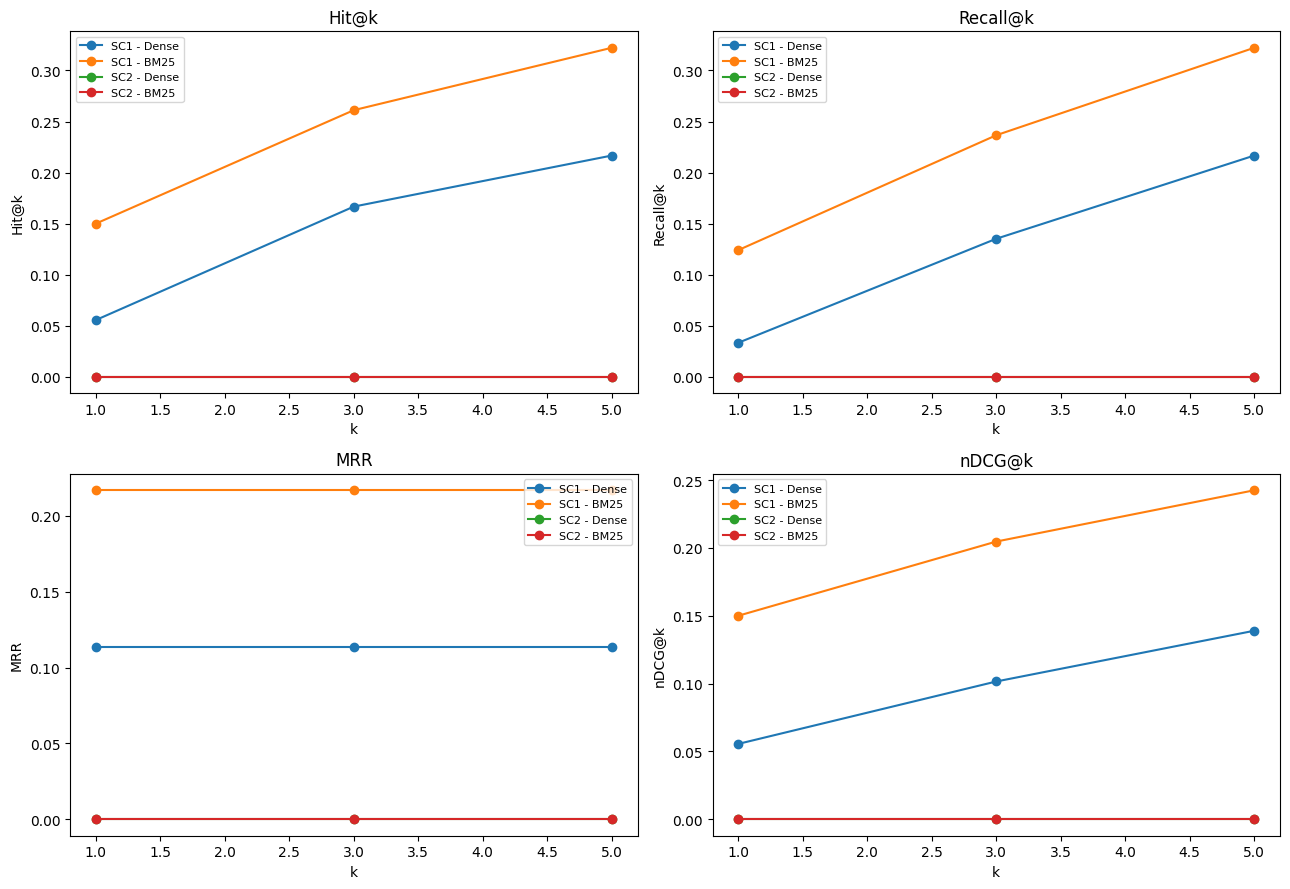

In [10]:
metrics = ['Hit@k', 'Recall@k', 'MRR', 'nDCG@k']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    for dataset_name in ['SC1', 'SC2']:
        for retriever_name in ['Dense', 'BM25']:
            sub = retrieval_results[
                (retrieval_results['dataset'] == dataset_name) &
                (retrieval_results['retriever'] == retriever_name)
            ]
            if sub.empty:
                continue

            ax.plot(sub['k'], sub[metric], marker='o', label=f'{dataset_name} - {retriever_name}')

    ax.set_title(metric)
    ax.set_xlabel('k')
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Optional: inspect judged examples


In [12]:
def preview_judgments(detail_dict, retriever_name='Dense', n=3):
    rows = detail_dict.get(retriever_name, [])[:n]
    for i, item in enumerate(rows, start=1):
        print(f'===== Example {i} =====')
        print('Query:', item['query'])
        print('Binary relevance labels:', item['binary_rels'])
        print()


print('SC1 Dense judgments:')
preview_judgments(details_sc1, 'Dense', n=3)

print('SC1 BM25 judgments:')
preview_judgments(details_sc1, 'BM25', n=3)


SC1 Dense judgments:
===== Example 1 =====
Query: In the field of natural language processing, what is the name of the technique where a large trained model is used to supervise the training of a smaller model by having the smaller model match the output probability distributions of the larger one?
Binary relevance labels: [0, 0, 0, 0, 0]

===== Example 2 =====
Query: In the field of natural language processing, what architecture did Vaswani et al. introduce in their 2017 paper 'Attention Is All You Need'?
Binary relevance labels: [0, 0, 0, 0, 0]

===== Example 3 =====
Query: In the field of natural language processing, what is the name of the automatic evaluation metric most commonly used to assess the quality of machine translation outputs, based on n-gram precision overlap between system output and reference translations?
Binary relevance labels: [0, 0, 1, 0, 0]

SC1 BM25 judgments:
===== Example 1 =====
Query: In the field of natural language processing, what is the name of the tec

In [13]:
print('SC2 Dense judgments:')
preview_judgments(details_sc2, 'Dense', n=3)

print('SC2 BM25 judgments:')
preview_judgments(details_sc2, 'BM25', n=3)

SC2 Dense judgments:
===== Example 1 =====
Query: What is the capital city of Afghanistan?
Binary relevance labels: [0, 0, 0, 0, 0]

===== Example 2 =====
Query: What is the capital city of Albania?
Binary relevance labels: [0, 0, 0, 0, 0]

===== Example 3 =====
Query: What is the capital city of Algeria?
Binary relevance labels: [0, 0, 0, 0, 0]

SC2 BM25 judgments:
===== Example 1 =====
Query: What is the capital city of Afghanistan?
Binary relevance labels: [0, 0, 0, 0, 0]

===== Example 2 =====
Query: What is the capital city of Albania?
Binary relevance labels: [0, 0, 0, 0, 0]

===== Example 3 =====
Query: What is the capital city of Algeria?
Binary relevance labels: [0, 0, 0, 0, 0]



In [ ]:
import pandas as pd

df = pd.read_parquet("data/sc1_output.parquet")
df.iloc[0]

In [ ]:
df = pd.read_parquet("data/sc2_output.parquet")
df.iloc[0]